# Regularização

Regularização é uma técnica utilizada em machine learning para prevenir overfitting, que ocorre quando um modelo se ajusta excessivamente aos dados de treinamento, capturando não apenas os padrões relevantes, mas também o ruído e as peculiaridades específicas desses dados. O objetivo da regularização é impor uma penalização para complexidade excessiva do modelo, incentivando-o a ser mais simples e, portanto, mais capaz de generalizar para novos dados.

### Como Funciona a Regularização

Regularização é geralmente implementada adicionando um termo de penalização à função de custo do modelo, que o modelo tenta minimizar durante o treinamento. Existem diferentes formas de regularização, sendo as mais comuns:

1. **L1 Regularization (Lasso)**:
   - Adiciona uma penalização proporcional à soma dos valores absolutos dos coeficientes do modelo.
   - Promove a sparsity, ou seja, a esparsidade, forçando alguns coeficientes a serem exatamente zero, o que pode resultar em um modelo mais interpretável ao selecionar automaticamente features relevantes.

2. **L2 Regularization (Ridge)**:
   - Adiciona uma penalização proporcional à soma dos quadrados dos coeficientes do modelo.
   - Reduz os coeficientes, mas dificilmente os torna exatamente zero, resultando em um modelo com todos os features ainda contribuintes, mas com impactos reduzidos.

3. **Elastic Net**:
   - Combina as penalizações L1 e L2, permitindo um equilíbrio entre a sparsity do Lasso e a suavização do Ridge.

### Importância da Regularização

1. **Prevenção do Overfitting**:
   - Regularização é essencial para prevenir o overfitting, especialmente em modelos complexos com muitos parâmetros. Sem regularização, um modelo pode se ajustar tão bem aos dados de treinamento que perde a capacidade de generalizar para novos dados.

2. **Melhor Generalização**:
   - Ao penalizar a complexidade, a regularização incentiva o modelo a ser mais robusto, capturando apenas os padrões verdadeiros dos dados. Isso resulta em melhor desempenho em dados de validação e teste, ou seja, dados que o modelo nunca viu antes.

3. **Simplicidade e Interpretabilidade**:
   - Em muitos casos, modelos simples são preferíveis por serem mais fáceis de interpretar. Regularização, especialmente L1, pode ajudar a criar modelos mais simples e interpretáveis ao eliminar features irrelevantes.

4. **Controle de Multicolinearidade**:
   - Em modelos de regressão linear, a multicolinearidade entre as features pode tornar os coeficientes instáveis e difíceis de interpretar. A regularização ajuda a estabilizar esses coeficientes, reduzindo a variância do modelo e melhorando a robustez.



## Exemplo simples - sem regularização

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PASTA_PROJETO = Path.cwd()
if PASTA_PROJETO.name == "notebooks":
    PASTA_PROJETO = PASTA_PROJETO.parent

if str(PASTA_PROJETO) not in sys.path:
    sys.path.append(str(PASTA_PROJETO))

from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.model_selection import train_test_split, ValidationCurveDisplay

from src.config import DADOS_EXEMPLO_REGULARIZACAO
from src.graficos import plot_residuos

sns.set_theme(palette="bright")

In [2]:
df = pd.read_csv(DADOS_EXEMPLO_REGULARIZACAO)

df.head()

,X,y
0,0.031998,6.112445
1,-0.112421,-8.107160
2,-0.140900,-3.848340
3,-0.061807,-0.999919
4,-0.076337,-5.174541


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       200 non-null    float64
 1   y       200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


<Axes: xlabel='X', ylabel='y'>

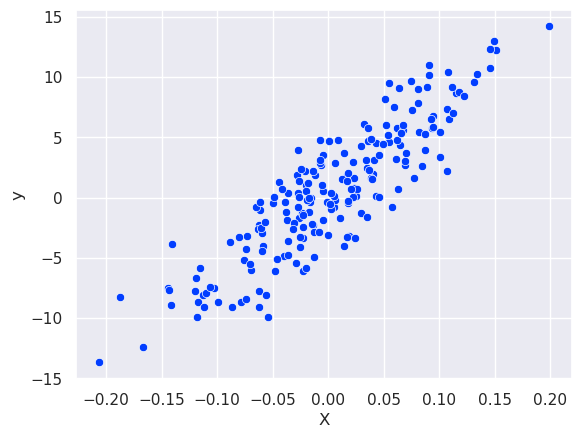

In [4]:
sns.scatterplot(data=df, x="X", y="y")

### Usando todos os dados

In [5]:
regressor_lr = LinearRegression()

X = df[["X"]]
y = df["y"]

regressor_lr.fit(X, y)

LinearRegression()

In [6]:
regressor_lr.coef_

array([67.96860913])

In [7]:
regressor_lr.intercept_

0.33871148651030003

In [8]:
regressor_lr.score(X, y)

0.784432686808289

In [9]:
y_pred_lr = regressor_lr.predict(X)

<Axes: xlabel='X', ylabel='y'>

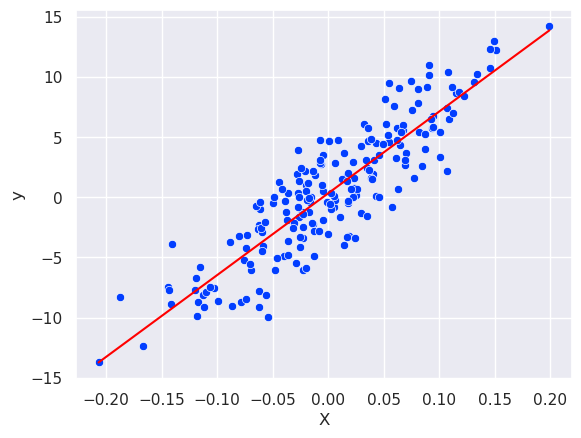

In [12]:
sns.scatterplot(data=df, x="X", y="y")
sns.lineplot(data=df, x="X", y=y_pred_lr, color="red")

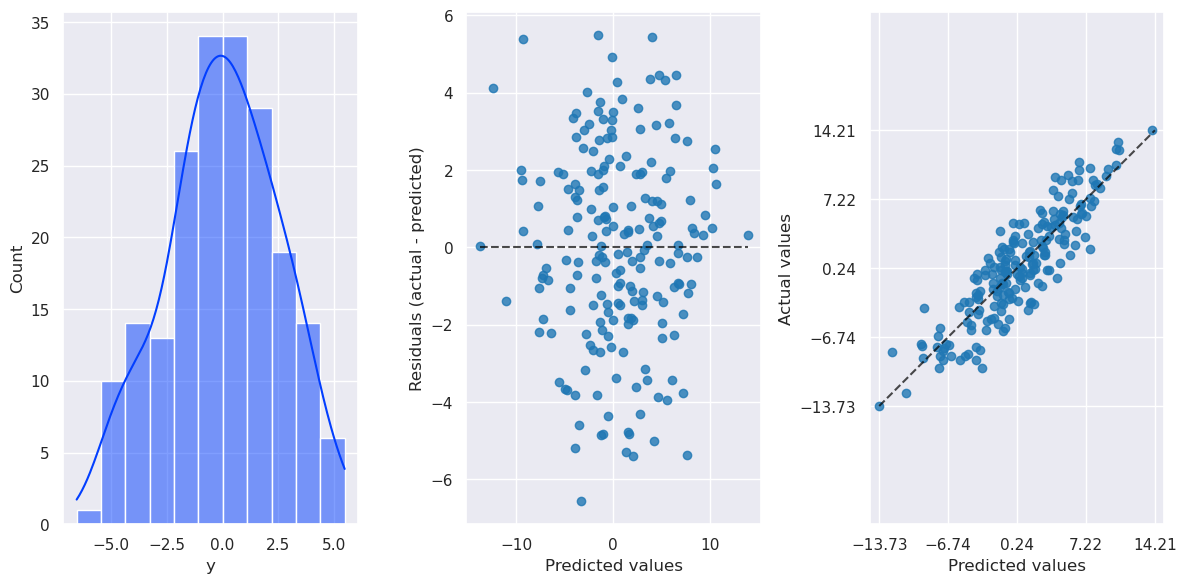

In [13]:
plot_residuos(y, y_pred_lr)

### Separando em treino e teste

## Ridge

**Ridge Regression**, também conhecida como **Regressão L2**, é uma técnica de regularização aplicada a modelos de regressão linear. O principal objetivo do Ridge é melhorar a capacidade de generalização do modelo, especialmente em cenários onde as features estão altamente correlacionadas ou onde o número de features é grande em comparação com o número de observações.

### Contexto da Regressão Linear

Na regressão linear simples, buscamos encontrar um vetor de pesos $ \mathbf{w} = [w_1, w_2, \dots, w_p] $ que minimiza a soma dos erros quadrados entre as previsões do modelo e os valores reais do target $ y $. A função de custo típica da regressão linear é dada por:

$$
J(\mathbf{w}) = \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 
$$

onde:
- $ n $ é o número de observações,
- $ y_i $ é o valor real da i-ésima observação,
- $ \hat{y}_i $ é a previsão do modelo para a i-ésima observação,

### Introdução da Regularização L2 (Ridge)

O Ridge Regression modifica a função de custo da regressão linear para incluir um termo de penalização que depende da magnitude dos pesos $ \mathbf{w} $. A função de custo regularizada em Ridge é dada por:

$$
J(\mathbf{w}) = \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 + \alpha \sum_{j=1}^{p} w_j^2
$$

onde:
- $ \alpha $ é o hiperparâmetro de regularização que controla a força da penalização,
- $ \sum_{j=1}^{p} w_j^2 $ é a soma dos quadrados dos pesos.

O termo de regularização $ \alpha \sum_{j=1}^{p} w_j^2 $ penaliza a função de custo original, incentivando o modelo a minimizar não apenas os erros de predição, mas também a magnitude dos pesos. Isso tem o efeito de:
- **Reduzir a variância**: Modelos complexos com pesos grandes podem se ajustar muito bem aos dados de treinamento, mas falham em generalizar para novos dados. A regularização força esses pesos a serem menores, criando um modelo que é mais robusto a novos dados.
- **Manter todas as features no modelo**: Diferentemente do Lasso, que pode reduzir alguns pesos a exatamente zero, eliminando features, o Ridge tende a manter todos os pesos não nulos, mas os diminui. Isso pode ser vantajoso em cenários onde todas as features são consideradas importantes, mas correlacionadas.

### Escolha do Hiperparâmetro $ \alpha $

O hiperparâmetro $ \alpha $ controla o trade-off entre o ajuste do modelo aos dados de treinamento e a penalização da magnitude dos pesos. Quando $ \alpha = 0 $, a regularização é removida e o modelo se torna equivalente à regressão linear simples. À medida que $ \alpha $ aumenta, a penalização se torna mais forte, resultando em pesos menores e, potencialmente, em um modelo menos suscetível ao overfitting.

A escolha do valor de $ \alpha $ é geralmente feita usando validação cruzada, onde diferentes valores de $ \alpha $ são testados para encontrar aquele que proporciona o melhor equilíbrio entre bias e variância.

### Vantagens do Ridge

1. **Redução do Overfitting**: Ao penalizar pesos grandes, o Ridge reduz a complexidade do modelo, ajudando a prevenir o overfitting.
2. **Estabilidade em Multicolinearidade**: Ridge é particularmente útil em situações onde as features são altamente correlacionadas, pois a regularização ajuda a estabilizar os coeficientes.

### Limitações do Ridge

1. **Todas as Features são Mantidas**: Como o Ridge tende a manter todos os coeficientes não nulos, ele não é útil se o objetivo é selecionar um subconjunto de features importantes.
2. **Interpretação**: Em cenários onde a interpretabilidade dos coeficientes é crucial, a regularização pode dificultar a interpretação direta dos pesos, pois eles são enviesados para reduzir a magnitude.


## Lasso

**Lasso Regression** (Least Absolute Shrinkage and Selection Operator) é uma técnica de regularização aplicada a modelos de regressão linear, que visa melhorar a capacidade de generalização do modelo e, ao mesmo tempo, realizar a seleção de features. Lasso é especialmente útil em situações onde se deseja identificar e utilizar apenas as features mais relevantes, eliminando aquelas que têm pouca ou nenhuma contribuição para o modelo.

### Contexto da Regressão Linear

Na regressão linear simples, o objetivo é encontrar um vetor de pesos $ \mathbf{w} = [w_1, w_2, \dots, w_p] $ que minimiza a soma dos erros quadrados entre as previsões do modelo e os valores reais do target $ y $. A função de custo da regressão linear padrão é dada por:

$$
J(\mathbf{w}) = \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 
$$

onde:
- $ n $ é o número de observações,
- $ y_i $ é o valor real da i-ésima observação,
- $ \hat{y}_i $ é a previsão do modelo para a i-ésima observação,

### Introdução da Regularização L1 (Lasso)

Lasso Regression modifica a função de custo da regressão linear para incluir um termo de penalização que depende da soma dos valores absolutos dos pesos $ \mathbf{w} $. A função de custo regularizada em Lasso é dada por:

$$
J(\mathbf{w}) = \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 + \alpha \sum_{j=1}^{p} |w_j|
$$

onde:
- $ \alpha $ é o hiperparâmetro de regularização que controla a força da penalização,
- $ \sum_{j=1}^{p} |w_j| $ é a soma dos valores absolutos dos pesos.

### Como Lasso Funciona

O termo de regularização $ \alpha \sum_{j=1}^{p} |w_j| $ adiciona uma penalização linear na função de custo original, o que incentiva o modelo a não apenas minimizar os erros de predição, mas também a reduzir o número de pesos não nulos. Isso resulta em:

- **Seleção de Features**: O Lasso pode forçar alguns dos coeficientes $ w_j $ a serem exatamente zero, efetivamente eliminando as features correspondentes do modelo. Isso faz do Lasso uma ferramenta poderosa para seleção de features.
  
- **Redução da Variância**: Ao simplificar o modelo e eliminar features irrelevantes, o Lasso ajuda a reduzir a variância, o que melhora a capacidade do modelo de generalizar para novos dados.

### Escolha do Hiperparâmetro $ \alpha $

O hiperparâmetro $ \alpha $ controla o trade-off entre ajuste e regularização. Quando $ \alpha = 0 $, o modelo se reduz à regressão linear padrão sem regularização. À medida que $ \alpha $ aumenta, mais coeficientes são reduzidos a zero, resultando em um modelo mais simples e com menos features.

A escolha de $ \alpha $ é crítica e geralmente é feita usando técnicas de validação cruzada. Escolher um $ \alpha $ adequado ajuda a equilibrar o modelo entre underfitting (quando $ \alpha $ é muito grande e muitos coeficientes são zerados) e overfitting (quando $ \alpha $ é muito pequeno e poucos coeficientes são penalizados).

### Vantagens do Lasso

1. **Seleção Automática de Features**: Uma das principais vantagens do Lasso é sua capacidade de selecionar automaticamente as features mais importantes ao forçar os coeficientes de features menos importantes a zero.

2. **Interpretação Simplificada**: Como o Lasso tende a eliminar features irrelevantes, o modelo resultante é mais simples e fácil de interpretar.

3. **Robustez contra Multicolinearidade**: Lasso pode ser particularmente útil em cenários com multicolinearidade (onde as features são altamente correlacionadas), pois ele seleciona uma ou poucas features entre as correlacionadas e zera as outras.

### Limitações do Lasso

1. **Número de Features Selecionadas**: Se houver muitas features correlacionadas, o Lasso pode selecionar apenas uma delas, ignorando outras que podem ser igualmente importantes.

2. **Cenários com Muitas Features e Poucos Dados**: Em situações onde o número de features é muito grande em comparação com o número de observações, o Lasso pode eliminar muitas features, potencialmente ignorando informações úteis.

3. **Bias dos Coeficientes**: Como o Lasso penaliza todos os coeficientes, ele introduz um viés no modelo. Isso pode levar a uma subestimação dos verdadeiros valores dos coeficientes.
